## Step 1 — Imports and Setup

In [18]:
# ============================================================
# Step 1: Import Libraries
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Set device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## Step 2 — Data Preparation (Task 1)

In [19]:
# ============================================================
# Step 2: Load and Prepare Data (Task 1)
# ============================================================

# --- 2a. Load CSV and keep only required columns ---
DATA_CSV = r'data (1).csv'    # Path to your CSV file
IMAGE_DIR = r'sampled_images'  # Path to your images folder

df = pd.read_csv(DATA_CSV)
# Keep the Filename, class label, and all 6 numerical pollutant features
df = df[['Filename', 'AQI_Class', 'PM2.5', 'PM10', 'O3', 'CO', 'SO2', 'NO2']].copy()

print(f"Total entries in CSV: {len(df)}")
print(f"\nClass distribution:\n{df['AQI_Class'].value_counts().sort_index()}")

# --- 2b. Verify which images actually exist ---
df['image_exists'] = df['Filename'].apply(
    lambda x: os.path.isfile(os.path.join(IMAGE_DIR, x))
)
print(f"\nImages found: {df['image_exists'].sum()} / {len(df)}")

# Keep only rows where image exists
df = df[df['image_exists']].drop(columns=['image_exists']).reset_index(drop=True)
print(f"Working with {len(df)} images")

# --- 2c. Encode labels to integers ---
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['AQI_Class'])
class_names = label_encoder.classes_
num_classes = len(class_names)

print(f"\nClasses ({num_classes}): {list(class_names)}")
print(f"Label mapping: {dict(zip(class_names, range(num_classes)))}")

# --- 2d. Split into Train (70%) / Validation (15%) / Test (15%) ---
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\nSplit sizes -> Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


# Define the numerical features to use
numerical_cols = ['PM2.5', 'PM10', 'O3', 'CO', 'SO2', 'NO2']

# 1. Fill missing values (NaNs) with the median of each column
imputer = SimpleImputer(strategy='median')
train_df[numerical_cols] = imputer.fit_transform(train_df[numerical_cols])
val_df[numerical_cols] = imputer.transform(val_df[numerical_cols])
test_df[numerical_cols] = imputer.transform(test_df[numerical_cols])

# 2. Scale features so they have mean=0 and variance=1
scaler = StandardScaler()
train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])
val_df[numerical_cols] = scaler.transform(val_df[numerical_cols])
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])


Total entries in CSV: 6000

Class distribution:
AQI_Class
a_Good                              1000
b_Moderate                          1000
c_Unhealthy_for_Sensitive_Groups    1000
d_Unhealthy                         1000
e_Very_Unhealthy                    1000
f_Severe                            1000
Name: count, dtype: int64

Images found: 6000 / 6000
Working with 6000 images

Classes (6): ['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']
Label mapping: {'a_Good': 0, 'b_Moderate': 1, 'c_Unhealthy_for_Sensitive_Groups': 2, 'd_Unhealthy': 3, 'e_Very_Unhealthy': 4, 'f_Severe': 5}

Split sizes -> Train: 4200, Val: 900, Test: 900


## Step 3 — Custom Dataset & DataLoaders

Batches -> Train: 132, Val: 29, Test: 29


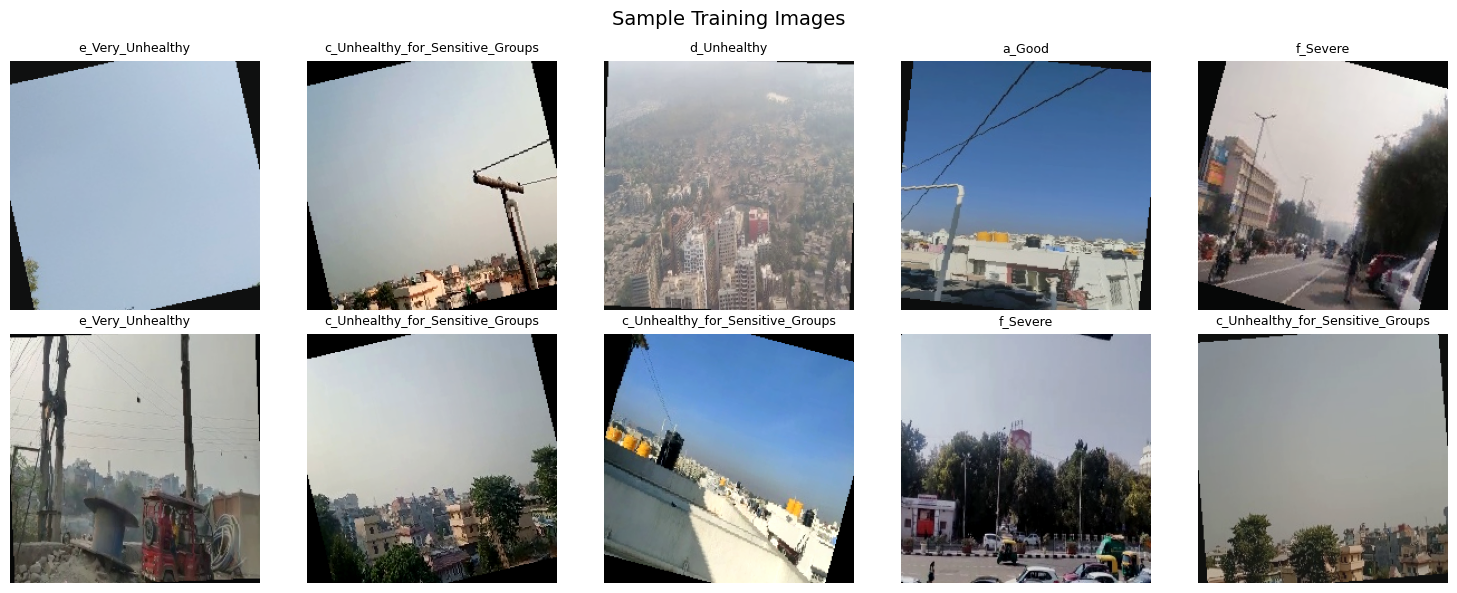

In [20]:
# ============================================================
# Step 3: Custom Dataset & DataLoaders
# ============================================================

class AQIDataset(Dataset):
    """Custom dataset for loading both images and numerical pollutant features."""
    def __init__(self, dataframe, img_dir, numerical_cols, transform=None):
        self.data = dataframe
        self.img_dir = img_dir
        self.numerical_cols = numerical_cols
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 1. Load image
        img_name = self.data.iloc[idx]['Filename']
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')  # Ensure 3 channels

        if self.transform:
            image = self.transform(image)
            
        # 2. Extract numerical features as a PyTorch Float32 Tensor
        num_features = self.data.iloc[idx][self.numerical_cols].values.astype(np.float32)
        num_features = torch.tensor(num_features)
        
        # 3. Extract label
        label = torch.tensor(self.data.iloc[idx]['label'], dtype=torch.long)

        return image, num_features, label


# --- Define transforms ---
# Training: add augmentations to make the model more robust
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test: no augmentation, just resize + normalize
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# --- Create datasets ---
# Pass numerical_cols to the dataset constructors
train_dataset = AQIDataset(train_df, IMAGE_DIR, numerical_cols=numerical_cols, transform=train_transform)
val_dataset   = AQIDataset(val_df, IMAGE_DIR, numerical_cols=numerical_cols, transform=val_test_transform)
test_dataset  = AQIDataset(test_df, IMAGE_DIR, numerical_cols=numerical_cols, transform=val_test_transform)


# --- Create data loaders ---
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches -> Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

# --- Visualize some training images ---
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img, num_feats, label = train_dataset[i]
    # Unnormalize for display
    img_display = img.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)
    ax.imshow(img_display)
    ax.set_title(class_names[label], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()


## Step 4 — Basic CNN Model (Task 2)

In [21]:
# ============================================================
# Step 4: Basic CNN Model (Task 2)
# ============================================================

class MultimodalCNN(nn.Module):
    def __init__(self, num_classes=6, num_numerical_features=6):
        super(MultimodalCNN, self).__init__()

        # Image feature extractor (CNN Branch)
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Numerical feature extractor (MLP Branch)
        self.numerical_branch = nn.Sequential(
            nn.Linear(num_numerical_features, 32),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(32)
        )

        # Classifier head combining both branches
        # 256 channels from image branch + 32 features from numerical branch = 288 dimensions
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 + 32, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, num_features):
        # 1. Image branch
        img_feats = self.features(image)
        img_feats = self.global_pool(img_feats)
        img_feats = img_feats.view(img_feats.size(0), -1)  # Flatten

        # 2. Numerical branch
        num_feats = self.numerical_branch(num_features)

        # 3. Concatenate (combine) branches
        combined = torch.cat((img_feats, num_feats), dim=1)

        # 4. Final classification
        logits = self.classifier(combined)
        return logits

# Instantiate the model
basic_cnn = MultimodalCNN(num_classes=num_classes, num_numerical_features=len(numerical_cols)).to(device)

print(basic_cnn)
print(f"\nTotal parameters: {sum(p.numel() for p in basic_cnn.parameters()):,}")


MultimodalCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1

## Step 5 — Training Function

In [22]:
# ============================================================
# Step 5: Training Function
# ============================================================

def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=5, model_name="Model"):
    """Train a model and return training history."""

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, num_features, labels in train_loader:
            images = images.to(device)
            num_features = num_features.to(device)
            labels = labels.to(device)
    
            outputs = model(images, num_features)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track metrics
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc = 100. * correct / total

        # --- Validation Phase ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, num_features, labels in val_loader:
                images = images.to(device)
                num_features = num_features.to(device)
                labels = labels.to(device)
                outputs = model(images, num_features)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_loss = val_running_loss / val_total
        val_acc = 100. * val_correct / val_total

        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Print progress
        print(f"[{model_name}] Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name.lower().replace(" ", "_")}.pth')

    print(f"\n[{model_name}] Best Validation Accuracy: {best_val_acc:.2f}%")
    return history


## Step 6 — Train the Basic CNN

In [23]:
# ============================================================
# Step 6: Train the Basic CNN
# ============================================================

NUM_EPOCHS = 5
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
basic_optimizer = optim.Adam(basic_cnn.parameters(), lr=LEARNING_RATE)

print("=" * 60)
print("Training Basic CNN from Scratch")
print("=" * 60)

basic_history = train_model(
    basic_cnn, train_loader, val_loader,
    criterion, basic_optimizer,
    num_epochs=NUM_EPOCHS, model_name="Basic CNN"
)


Training Basic CNN from Scratch
[Basic CNN] Epoch [1/5] Train Loss: 1.1895 | Train Acc: 51.67% | Val Loss: 0.9359 | Val Acc: 58.11%
[Basic CNN] Epoch [2/5] Train Loss: 0.8060 | Train Acc: 66.83% | Val Loss: 0.5948 | Val Acc: 76.44%
[Basic CNN] Epoch [3/5] Train Loss: 0.6825 | Train Acc: 71.14% | Val Loss: 0.4203 | Val Acc: 85.44%
[Basic CNN] Epoch [4/5] Train Loss: 0.5858 | Train Acc: 76.17% | Val Loss: 0.3755 | Val Acc: 83.78%
[Basic CNN] Epoch [5/5] Train Loss: 0.5046 | Train Acc: 80.26% | Val Loss: 0.3264 | Val Acc: 87.00%

[Basic CNN] Best Validation Accuracy: 87.00%


## Updated Step 7 — Pretrained CNN Model / Transfer Learning Freeze Only First 10 Layers

In [24]:
# ============================================================
# Step 7: Pretrained CNN Model - Transfer Learning (Task 3)
#         Freeze only the first 10 layers of ResNet18
# ============================================================

class MultimodalResNet18(nn.Module):
    def __init__(self, num_classes=6, num_numerical_features=6, freeze_upto=10):
        super(MultimodalResNet18, self).__init__()
        
        # Load pretrained ResNet18
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        
        # Freeze only the first few layers (children)
        children = list(resnet.children())
        for idx, child in enumerate(children):
            if idx < freeze_upto:
                for param in child.parameters():
                    param.requires_grad = False  # Frozen
            else:
                for param in child.parameters():
                    param.requires_grad = True   # Trainable
        
        # Extract features (exclude the original fc layer)
        self.image_backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.image_feature_dim = resnet.fc.in_features  # 512
        
        # Numerical branch
        self.numerical_branch = nn.Sequential(
            nn.Linear(num_numerical_features, 32),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(32)
        )
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512 + 32, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, image, num_features):
        img_feats = self.image_backbone(image)
        img_feats = torch.flatten(img_feats, 1)
        
        num_feats = self.numerical_branch(num_features)
        
        combined = torch.cat((img_feats, num_feats), dim=1)
        logits = self.classifier(combined)
        return logits

# Instantiate pretrained Multimodal model
pretrained_model = MultimodalResNet18(
    num_classes=num_classes, 
    num_numerical_features=len(numerical_cols),
    freeze_upto=10
).to(device)

# --- Verify: count frozen vs trainable parameters ---
total_params = sum(p.numel() for p in pretrained_model.parameters())
trainable_params = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\nParameter Summary:")
print(f"  Total params:     {total_params:,}")
print(f"  Frozen params:    {frozen_params:,}")
print(f"  Trainable params: {trainable_params:,}")
print(f"  Trainable %:      {100 * trainable_params / total_params:.1f}%")

# --- Optimizer: train ONLY the parameters that require gradients ---
pretrained_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, pretrained_model.parameters()),
    lr=LEARNING_RATE
)

print("\n" + "=" * 60)
print("Training Pretrained Multimodal ResNet18 (First 10 Layers Frozen)")
print("=" * 60)

pretrained_history = train_model(
    pretrained_model, train_loader, val_loader,
    criterion, pretrained_optimizer,
    num_epochs=NUM_EPOCHS, model_name="Pretrained ResNet18"
)



Parameter Summary:
  Total params:     11,317,862
  Frozen params:    11,176,512
  Trainable params: 141,350
  Trainable %:      1.2%

Training Pretrained Multimodal ResNet18 (First 10 Layers Frozen)
[Pretrained ResNet18] Epoch [1/5] Train Loss: 1.2276 | Train Acc: 49.31% | Val Loss: 0.8117 | Val Acc: 68.22%
[Pretrained ResNet18] Epoch [2/5] Train Loss: 0.8928 | Train Acc: 62.36% | Val Loss: 0.6258 | Val Acc: 77.22%
[Pretrained ResNet18] Epoch [3/5] Train Loss: 0.7559 | Train Acc: 69.36% | Val Loss: 0.6090 | Val Acc: 72.67%
[Pretrained ResNet18] Epoch [4/5] Train Loss: 0.6800 | Train Acc: 71.60% | Val Loss: 0.5124 | Val Acc: 77.00%
[Pretrained ResNet18] Epoch [5/5] Train Loss: 0.6392 | Train Acc: 73.98% | Val Loss: 0.3796 | Val Acc: 83.89%

[Pretrained ResNet18] Best Validation Accuracy: 83.89%


## Step 8 — Evaluation Function (Task 4)


############################################################
EVALUATING BASIC CNN ON TEST SET
############################################################

Classification Report - Basic CNN
                                  precision    recall  f1-score   support

                          a_Good       0.79      0.99      0.88       150
                      b_Moderate       0.94      0.74      0.83       150
c_Unhealthy_for_Sensitive_Groups       0.96      0.74      0.83       150
                     d_Unhealthy       0.86      0.91      0.88       150
                e_Very_Unhealthy       0.90      0.95      0.93       150
                        f_Severe       0.95      1.00      0.97       150

                        accuracy                           0.89       900
                       macro avg       0.90      0.89      0.89       900
                    weighted avg       0.90      0.89      0.89       900

Overall -> Accuracy: 0.8900 | Precision: 0.8985 | Recall: 0.8900 |

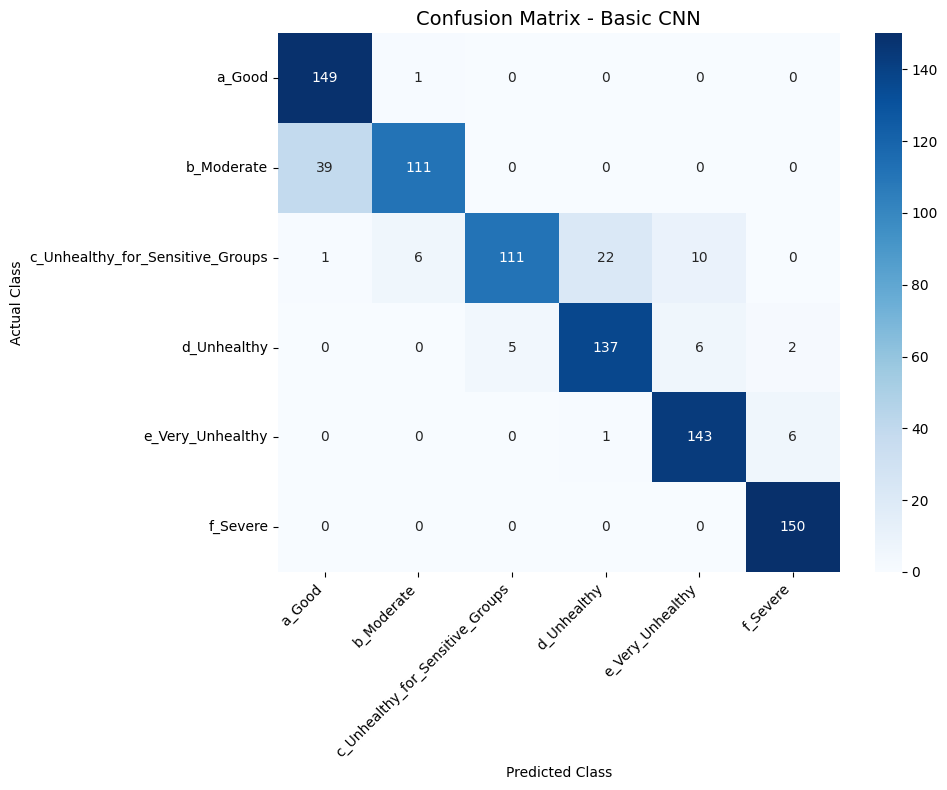


############################################################
EVALUATING PRETRAINED RESNET18 ON TEST SET
############################################################

Classification Report - Pretrained ResNet18
                                  precision    recall  f1-score   support

                          a_Good       0.79      0.85      0.82       150
                      b_Moderate       0.73      0.82      0.77       150
c_Unhealthy_for_Sensitive_Groups       0.95      0.61      0.74       150
                     d_Unhealthy       0.79      0.89      0.84       150
                e_Very_Unhealthy       0.95      0.87      0.91       150
                        f_Severe       0.89      1.00      0.94       150

                        accuracy                           0.84       900
                       macro avg       0.85      0.84      0.84       900
                    weighted avg       0.85      0.84      0.84       900

Overall -> Accuracy: 0.8400 | Precision: 0.850

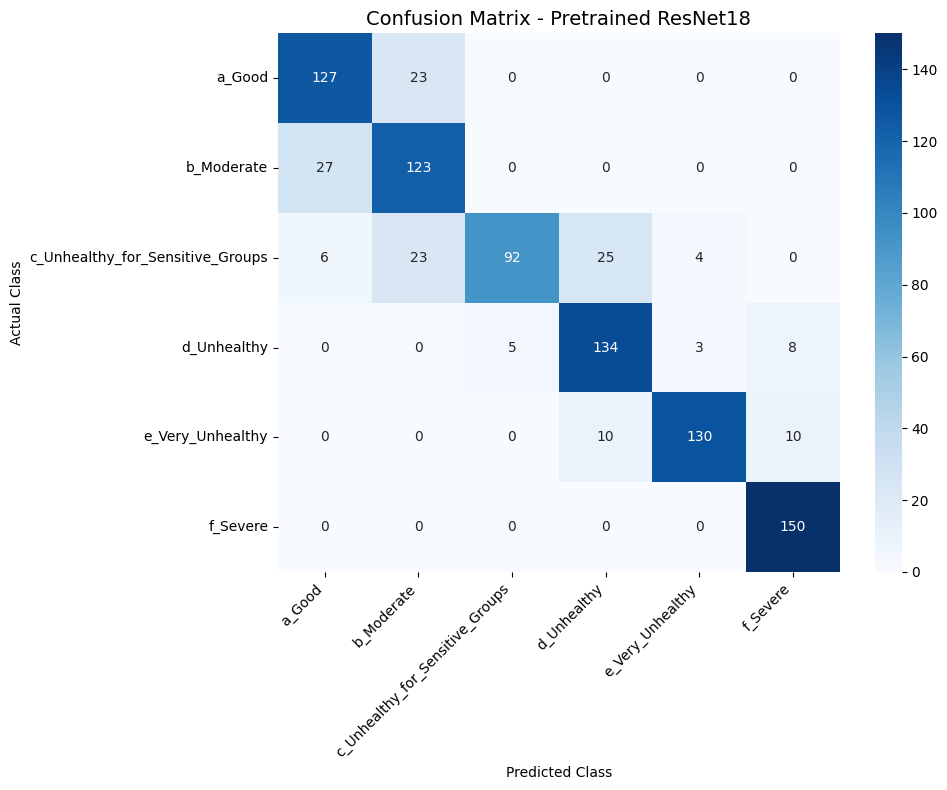


MODEL COMPARISON
   Metric  Basic CNN  Pretrained ResNet18
 Accuracy   0.890000             0.840000
Precision   0.898487             0.850779
   Recall   0.890000             0.840000
 F1-Score   0.887577             0.837483


In [25]:
# ============================================================
# Step 8: Evaluation Function (Task 4)
# ============================================================

def evaluate_model(model, test_loader, class_names, model_name="Model"):
    """Evaluate model on test set and return predictions."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, num_features, labels in test_loader:
            images = images.to(device)
            num_features = num_features.to(device)
            outputs = model(images, num_features)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Classification Report
    print(f"\n{'='*60}")
    print(f"Classification Report - {model_name}")
    print(f"{'='*60}")
    print(classification_report(all_labels, all_preds,
                                target_names=class_names))

    # Overall metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Overall -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | "
          f"Recall: {rec:.4f} | F1-Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}', fontsize=14)
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels, {'accuracy': acc, 'precision': prec,
                                    'recall': rec, 'f1': f1}


# --- Evaluate both models ---
print("\n" + "#" * 60)
print("EVALUATING BASIC CNN ON TEST SET")
print("#" * 60)
basic_cnn.load_state_dict(torch.load('best_basic_cnn.pth'))
basic_preds, basic_labels, basic_metrics = evaluate_model(
    basic_cnn, test_loader, class_names, "Basic CNN"
)

print("\n" + "#" * 60)
print("EVALUATING PRETRAINED RESNET18 ON TEST SET")
print("#" * 60)
pretrained_model.load_state_dict(torch.load('best_pretrained_resnet18.pth'))
pretrained_preds, pretrained_labels, pretrained_metrics = evaluate_model(
    pretrained_model, test_loader, class_names, "Pretrained ResNet18"
)

# --- Comparison Table ---
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Basic CNN': [basic_metrics['accuracy'], basic_metrics['precision'],
                  basic_metrics['recall'], basic_metrics['f1']],
    'Pretrained ResNet18': [pretrained_metrics['accuracy'], pretrained_metrics['precision'],
                            pretrained_metrics['recall'], pretrained_metrics['f1']]
})
print(comparison.to_string(index=False))


## Step 9 — Training Curves (Task 5)

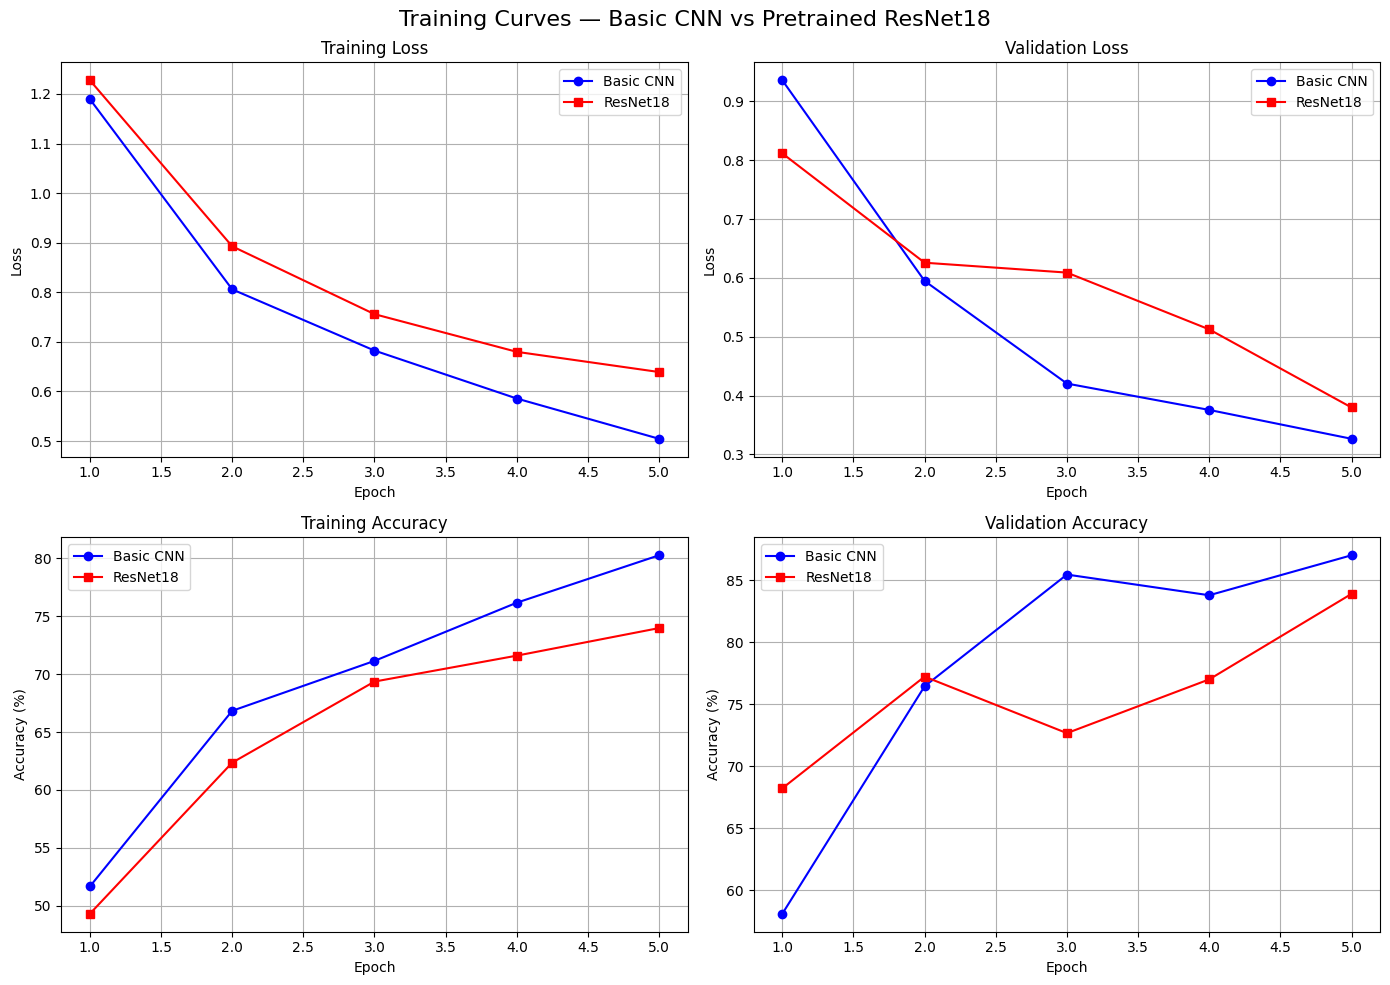


DISCUSSION: Why Pretrained Models Often Outperform Models Trained from Scratch
1. **Feature Reuse:** Pretrained models (like ResNet18) were trained on ImageNet
   (1.2 million images). They already know how to detect edges, textures, colors,
   and shapes. These low-level features are useful for almost ANY image task,
   including AQI classification.

2. **Limited Data:** With ~4,200 training images, a model built from scratch
   struggles to learn all these features from zero. The pretrained model already
   has this knowledge, so it only needs to learn the AQI-specific patterns.

3. **Faster Convergence:** Transfer learning typically converges faster because
   the feature extraction layers are already optimized. Only the classifier
   on top needs training.

4. **Regularization Effect:** Frozen pretrained weights act as a form of
   regularization, reducing overfitting on the small training dataset.

Did transfer learning help on this dataset?
- If ResNet18 achieved higher validati

In [26]:
# ============================================================
# Step 9: Training Curves (Task 5)
# ============================================================

def plot_training_curves(basic_history, pretrained_history):
    """Plot training curves for both models."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = range(1, len(basic_history['train_loss']) + 1)

    # Training Loss
    axes[0, 0].plot(epochs, basic_history['train_loss'], 'b-o', label='Basic CNN')
    axes[0, 0].plot(epochs, pretrained_history['train_loss'], 'r-s', label='ResNet18')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # Validation Loss
    axes[0, 1].plot(epochs, basic_history['val_loss'], 'b-o', label='Basic CNN')
    axes[0, 1].plot(epochs, pretrained_history['val_loss'], 'r-s', label='ResNet18')
    axes[0, 1].set_title('Validation Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # Training Accuracy
    axes[1, 0].plot(epochs, basic_history['train_acc'], 'b-o', label='Basic CNN')
    axes[1, 0].plot(epochs, pretrained_history['train_acc'], 'r-s', label='ResNet18')
    axes[1, 0].set_title('Training Accuracy')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # Validation Accuracy
    axes[1, 1].plot(epochs, basic_history['val_acc'], 'b-o', label='Basic CNN')
    axes[1, 1].plot(epochs, pretrained_history['val_acc'], 'r-s', label='ResNet18')
    axes[1, 1].set_title('Validation Accuracy')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.suptitle('Training Curves — Basic CNN vs Pretrained ResNet18', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_training_curves(basic_history, pretrained_history)

# --- Discussion ---
print("""
DISCUSSION: Why Pretrained Models Often Outperform Models Trained from Scratch
===============================================================================
1. **Feature Reuse:** Pretrained models (like ResNet18) were trained on ImageNet
   (1.2 million images). They already know how to detect edges, textures, colors,
   and shapes. These low-level features are useful for almost ANY image task,
   including AQI classification.

2. **Limited Data:** With ~4,200 training images, a model built from scratch
   struggles to learn all these features from zero. The pretrained model already
   has this knowledge, so it only needs to learn the AQI-specific patterns.

3. **Faster Convergence:** Transfer learning typically converges faster because
   the feature extraction layers are already optimized. Only the classifier
   on top needs training.

4. **Regularization Effect:** Frozen pretrained weights act as a form of
   regularization, reducing overfitting on the small training dataset.

Did transfer learning help on this dataset?
- If ResNet18 achieved higher validation/test accuracy with less overfitting,
  then YES — transfer learning clearly helped.
- The improvement is typically more significant on smaller datasets like this one.
""")


## Step 10 — Misclassification Analysis (Task 6)


Total misclassified in test set: found at least 10


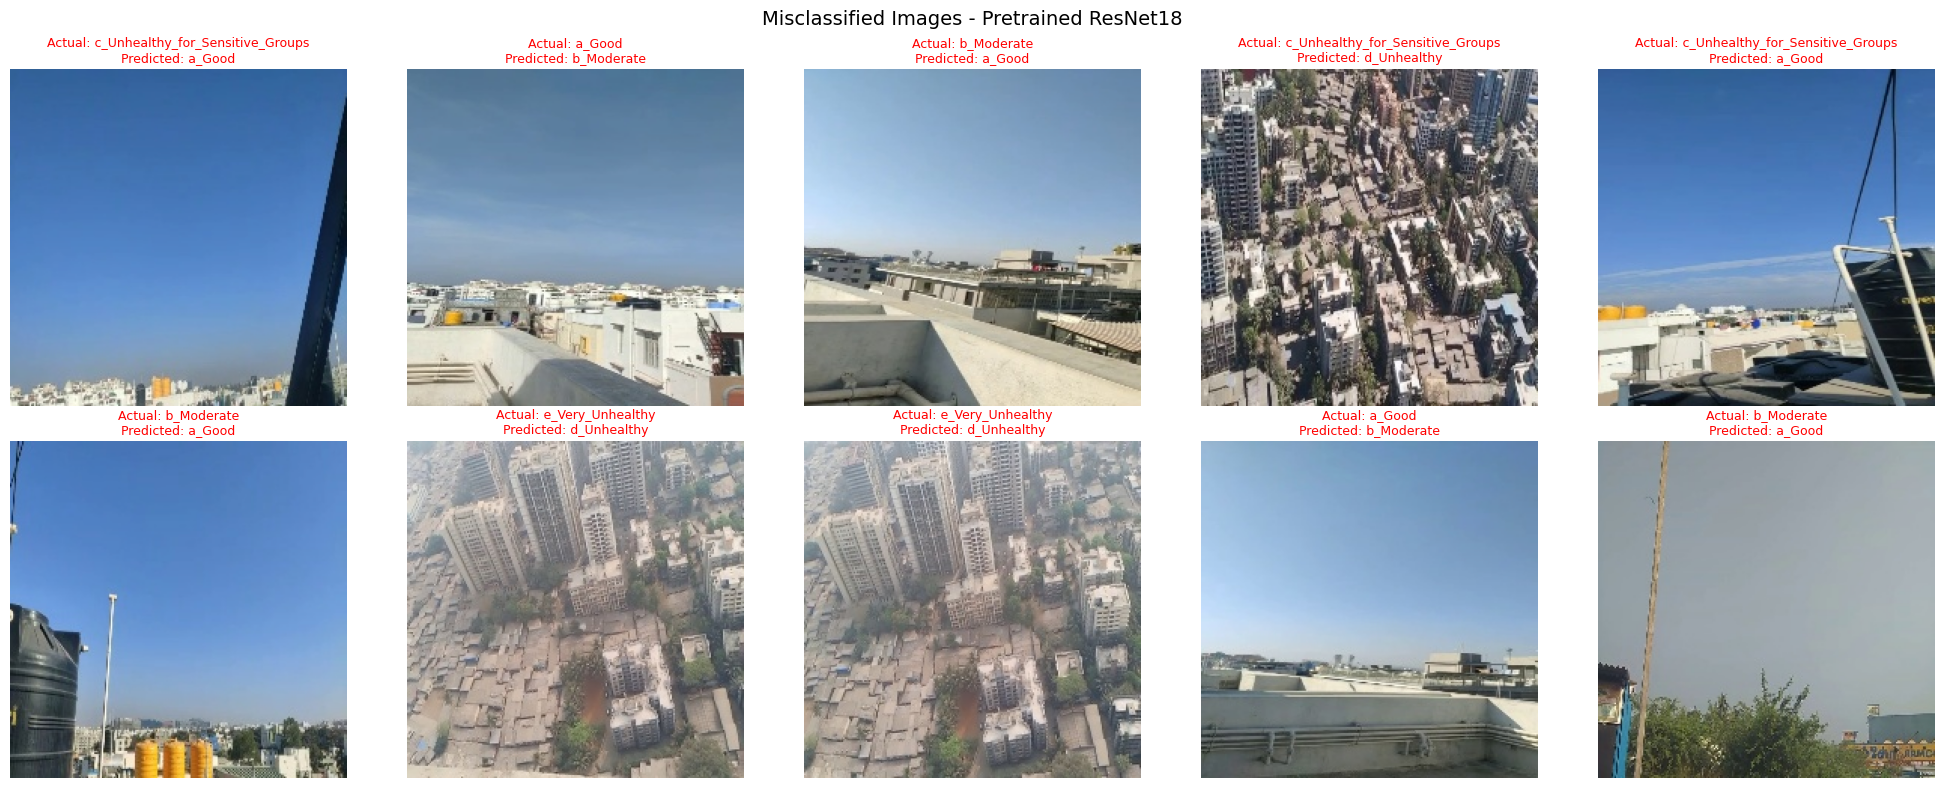


POSSIBLE REASONS FOR MISCLASSIFICATION:
1. **Adjacent Classes:** The AQI classes are ordered (Good -> Severe), and
   adjacent classes (e.g., Moderate vs Unhealthy_for_Sensitive_Groups) look
   very similar visually. The difference in haze level can be subtle.

2. **Lighting Conditions:** Images taken at different times of day (morning
   fog vs evening smog) can look similar even with different AQI levels.

3. **Geographic Variation:** Different cities have different landscapes.
   A "Good" day in Delhi might look visually similar to a "Moderate" day
   in Bangalore due to geography and camera placement differences.

4. **Image Quality:** Some images may be low resolution or have artifacts
   (camera shake, lens flare) that confuse the model.

5. **Limited Training Data:** With ~700 training images per class, the model
   hasn't seen enough diversity to perfectly distinguish all edge cases.

6. **Weather Effects:** Fog, mist, and clouds can mimic pollution haze,
   causing the model 

In [28]:
# ============================================================
# Step 10: Misclassification Analysis (Task 6)
# ============================================================

def show_misclassifications(model, test_dataset, test_df, class_names,
                            model_name="Model", num_images=10):
    """Show misclassified images with actual and predicted labels."""
    model.eval()

    misclassified_indices = []
    misclassified_preds = []
    misclassified_labels = []

    with torch.no_grad():
        for idx in range(len(test_dataset)):
            image, num_features, label = test_dataset[idx]
            image_input = image.unsqueeze(0).to(device)
            num_input = num_features.unsqueeze(0).to(device)
            output = model(image_input, num_input)
            _, predicted = output.max(1)
            pred = predicted.item()

            if pred != label:
                misclassified_indices.append(idx)
                misclassified_preds.append(pred)
                misclassified_labels.append(label)

            if len(misclassified_indices) >= num_images:
                break

    print(f"\nTotal misclassified in test set: found at least {len(misclassified_indices)}")
    n_show = min(num_images, len(misclassified_indices))

    if n_show == 0:
        print("No misclassifications found!")
        return

    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flat if n_show > 1 else [axes]

    for i in range(n_show):
        idx = misclassified_indices[i]
        img, _, actual_label = test_dataset[idx]

        # Unnormalize for display
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * np.array([0.229, 0.224, 0.225]) + \
                      np.array([0.485, 0.456, 0.406])
        img_display = np.clip(img_display, 0, 1)

        axes[i].imshow(img_display)
        axes[i].set_title(
            f"Actual: {class_names[actual_label]}\n"
            f"Predicted: {class_names[misclassified_preds[i]]}",
            fontsize=9, color='red'
        )
        axes[i].axis('off')

    # Hide empty subplots
    for j in range(n_show, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Misclassified Images - {model_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

# Show misclassified images for the pretrained model
show_misclassifications(
    pretrained_model, test_dataset, test_df, class_names,
    model_name="Pretrained ResNet18", num_images=10
)

# --- Possible Reasons for Misclassification ---
print("""
POSSIBLE REASONS FOR MISCLASSIFICATION:
========================================
1. **Adjacent Classes:** The AQI classes are ordered (Good -> Severe), and
   adjacent classes (e.g., Moderate vs Unhealthy_for_Sensitive_Groups) look
   very similar visually. The difference in haze level can be subtle.

2. **Lighting Conditions:** Images taken at different times of day (morning
   fog vs evening smog) can look similar even with different AQI levels.

3. **Geographic Variation:** Different cities have different landscapes.
   A "Good" day in Delhi might look visually similar to a "Moderate" day
   in Bangalore due to geography and camera placement differences.

4. **Image Quality:** Some images may be low resolution or have artifacts
   (camera shake, lens flare) that confuse the model.

5. **Limited Training Data:** With ~700 training images per class, the model
   hasn't seen enough diversity to perfectly distinguish all edge cases.

6. **Weather Effects:** Fog, mist, and clouds can mimic pollution haze,
   causing the model to misclassify clean-air images as polluted.
""")
